In [91]:
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import cartopy.io.shapereader as shpreader

### File paths

In [92]:
production_fn = '../../resources/production.csv'

### Workflow

In [93]:
# %%
# Load OWID iron ore data: https://ourworldindata.org/explorers/minerals?tab=map&Mineral=Iron+ore&Metric=Production&Type=Mine%2C+crude+ore&Share+of+global=false&country=OWID_WRL~AUS~CHL~CHN~USA
df = pd.read_csv("../../data/owid-iron-ore/iron-ore-crude-ore-production.csv")

# Rename columns for easier access
df.rename(columns={
    'Entity': 'Country',
    'Year': 'Year',
    'production|Iron ore|Mine, crude ore|tonnes': 'IronOreProduction',
    'crude ore|tonnes': 'CrudeOreTonnes'
}, inplace=True)

# Keep only rows with available iron ore production data
df = df.dropna(subset=['IronOreProduction'])

# Get latest year per country
df_latest = df.sort_values('Year').groupby('Country', as_index=False).last()

In [94]:
# Use cartopy to get natural earth countries shapefile
shapename = 'admin_0_countries'
reader = shpreader.natural_earth(resolution='110m',
                                 category='cultural',
                                 name=shapename)

world = gpd.read_file(reader)

# Merge country names — use left join to preserve geometry
merged = world.merge(df_latest, how='left', left_on='ADMIN', right_on='Country')


In [95]:
# %%
# Convert to gigatonnes
merged['IronOreProductionGt'] = merged['IronOreProduction'].divide(1e6) # tonnes to Gt

In [96]:
# Ensure ISO_A3 and IronOreProductionGt exist
filtered_df = merged[
    (merged['IronOreProductionGt'] > 0) & 
    (merged['ISO_A2'].notna())
][['ISO_A2', 'IronOreProductionGt', 'ADMIN']]
# Set ISO_A2 as index
production = filtered_df.set_index('ISO_A2')

# Display result
production.to_csv(production_fn)


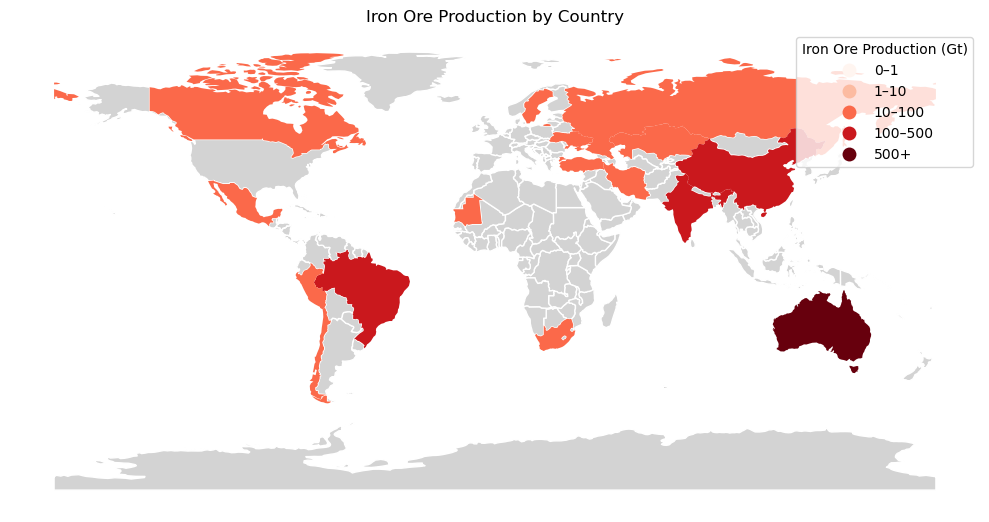

In [97]:

# Define Gt bins and labels
bins = [0, 1, 10, 100, 500, float('inf')]
labels = ['0–1', '1–10', '10–100', '100–500', '500+']

# Bin into categories
merged['ProductionCategory'] = pd.cut(
    merged['IronOreProductionGt'],
    bins=bins,
    labels=labels,
    include_lowest=True
)

# %%
# Plot
fig, ax = plt.subplots(figsize=(10, 7))

# Base world map
world.plot(ax=ax, color='lightgrey', edgecolor='white')

# Plot with categorical Gt bins
merged.dropna(subset=['ProductionCategory']).plot(
    ax=ax,
    column='ProductionCategory',
    cmap='Reds',
    legend=True,
    legend_kwds={'title': "Iron Ore Production (Gt)"},
    missing_kwds={"color": "lightgrey"}
)

ax.set_title(f"Iron Ore Production by Country")
ax.axis('off')
plt.tight_layout()
plt.show()
